# 0. Carga de datos brutos

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import geopandas as gpd
from shapely import wkt
from google.cloud import bigquery
import unicodedata

import sys
import os
sys.path.append(os.path.abspath('..'))

from pre_procesado.common_pipeline import run_global_pipeline
from utils_entrenamiento import walk_forward_split
from pre_procesado.non_linear_pipeline import build_tree_pipeline
from utils_entrenamiento import plot_shap_summary, evaluate_classification

import shap
from tqdm.auto import tqdm 

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\google\api_core\_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.25). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\google\oauth2\__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-a

In [4]:
client = bigquery.Client(project="project3grupo1")
query = """
WITH listings_dedup AS (
    SELECT *
    FROM `project3grupo1.airbnb_raw.listings`
    QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY snapshot_date DESC) = 1
),

events_agg AS (
    SELECT 
        start_date,
        COUNTIF(category = 'sports') as num_sports,
        COUNTIF(category = 'festivals') as num_festivals,
        SUM(phq_attendance) as total_attendance
    FROM `project3grupo1.airbnb_features.events`
    GROUP BY start_date
),

holidays_valencia AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_features.holidays`
    WHERE applies_to_valencia = True
),

calendar_dates AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_raw.calendar`
),

days_to_holiday AS (
    SELECT
        cd.date,
        MIN(DATE_DIFF(h.date, cd.date, DAY)) as days_to_next_holiday
    FROM calendar_dates cd
    LEFT JOIN holidays_valencia h ON h.date >= cd.date
    GROUP BY cd.date
)

SELECT
    -- Identificadores añadidos
    c.listing_id,

    -- Target
    CASE WHEN c.available = False THEN 1 ELSE 0 END as is_occupied,

    -- Temporales
    c.date,
    EXTRACT(MONTH FROM c.date) as month,
    EXTRACT(DAYOFWEEK FROM c.date) as day_of_week,
    IF(EXTRACT(DAYOFWEEK FROM c.date) IN (1,7), 1, 0) as is_weekend,
    COALESCE(dh.days_to_next_holiday, 0) as days_to_next_holiday,
    IF(h.date IS NOT NULL, 1, 0) as is_holiday,

    -- Del piso
    l.neighbourhood_cleansed,
    l.room_type,
    l.accommodates,
    l.price as listing_price,
    l.minimum_nights,
    l.number_of_reviews,
    l.review_scores_rating,
    IF(l.number_of_reviews > 0, 1, 0) as has_reviews,
    l.instant_bookable,

    -- Meteorología
    w.temp_mean,
    w.precipitation_mm,

    -- Eventos
    COALESCE(e.num_sports, 0) as num_sports,
    COALESCE(e.num_festivals, 0) as num_festivals,
    COALESCE(e.total_attendance, 0) as total_attendance

FROM `project3grupo1.airbnb_raw.calendar` c
LEFT JOIN listings_dedup l ON c.listing_id = l.id
LEFT JOIN `project3grupo1.airbnb_features.weather` w ON c.date = w.date
LEFT JOIN events_agg e ON c.date = e.start_date
LEFT JOIN holidays_valencia h ON c.date = h.date
LEFT JOIN days_to_holiday dh ON c.date = dh.date
WHERE c.date <= '2026-05-19'
QUALIFY ROW_NUMBER() OVER (PARTITION BY c.listing_id, c.date ORDER BY c.date DESC) = 1
"""

df_raw = client.query(query).to_dataframe()
print(f"Datos brutos cargados desde BQ: {df_raw.shape}")

Datos brutos cargados desde BQ: (3376585, 22)


# 2. Instanciar pipeline y ejecutarlo sobre los datos

In [5]:
from pre_procesado.common_pipeline import run_global_pipeline
from utils_entrenamiento import walk_forward_split

print(" Iniciando Pipeline Global...")
df_processed = run_global_pipeline(df_raw, max_lag=14)

# 2. Generar los índices para el Walk-Forward Validation
print("\nGenerando particiones temporales")
folds = walk_forward_split(
    df_processed, 
    date_col='date', 
    n_folds=4,           # Prueba con 4 ventanas
    val_months=1,        # Predecir 1 mes al futuro
    min_train_months=8   # Entrenar al menos con 8 meses históricos
)

# Solo primer fold
# Experimentos para encontrar las variables más relevantes -> acortamos el bucle
train_idx, val_idx = folds[0]

# Separar X e y
target = 'is_occupied'

# Guardamos el ID y Date aparte por si los necesitamos para análisis post-mortem
# pero no se los damos a las matrices de entrenamiento
metadata_cols = ['listing_id', 'date']

# Train
X_train_raw = df_processed.loc[train_idx].drop(columns=[target] + metadata_cols)
y_train = df_processed.loc[train_idx, target]

# Validación
X_val_raw = df_processed.loc[val_idx].drop(columns=[target] + metadata_cols)
y_val = df_processed.loc[val_idx, target]

print(f"\n✅ Datos listos para inyectar en los Pipelines:")
print(f"   X_train: {X_train_raw.shape} | X_val: {X_val_raw.shape}")

 Iniciando Pipeline Global...
🔧 PIPELINE GLOBAL (FASE 1)
[Duplicados] Eliminadas 0 filas (0.00%). Retenidas: 3376585
[MNAR Flags] Creadas 1 variables indicadoras: ['is_missing_review_scores_rating']
[Lags Individuales] Creados 13 lags (2 a 14) sobre 'is_occupied' agrupados por listing_id.
[Rachas] Creadas 'streak_occupied' y 'streak_vacant' con shift(2).
[Barrio Features] Creadas: 'occ_barrio_ayer', 'occ_barrio_ma7', 'price_ratio_barrio'.
[Cíclicas] Creadas 'day_sin' y 'day_cos' a partir de 'day_of_week'.
[Casteo] Variables residuales binarizadas y features numéricas casteadas a float64.

------------------------------------------------------------
✅ Pipeline Global completado.
   Filas: 3376585 -> 3376585 | Columnas nuevas: +21
   Shape final: (3376585, 43)

Generando particiones temporales
  Fold 1: Train [2025-06..2026-01] (2,051,101 rows) | Val [2026-02..2026-02] (343,644 rows)
  Fold 2: Train [2025-06..2026-02] (2,394,745 rows) | Val [2026-03..2026-03] (380,463 rows)
  Fold 3: Tra

# 3. Instanciar modelo lineal y entrenar

**1º "Kitchen Sink Approach" (Echar todo lo que tienes a la olla)**

**2º "Feature Pruning" en base a SHAP values**

esto hay que cambiarlo es una chapuza

In [6]:
# 3. Instanciar el pipeline de Árboles
print("\n Construyendo Pipeline Árboles")
prep_tree = build_tree_pipeline(
    cat_col='neighbourhood_cleansed',
    target_col=target,
    lag_prefix='is_occupied_lag_',
    top_k_lags=5,          # El pipeline calculará MI y se quedará solo con los 5 mejores lags
    mi_sample_frac=0.3,
    drop_cols=['listing_id', 'date'] # Metadatos a borrar
)

# 4. Fit y Transform al TRAIN
print(" Entrenando preprocesador de árboles (MI)")
prep_tree.fit(X_train_raw, y_train)
X_train_tree = prep_tree.transform(X_train_raw)

# 5. Transform al VAL
X_val_tree = prep_tree.transform(X_val_raw)

print(f" Dimensiones finales -> Train: {X_train_tree.shape} | Val: {X_val_tree.shape}")


🌲 Construyendo Pipeline Árboles (Experimento 2)...
[Pipeline Árboles] Construido: TreePreprocessor (Sin escalado, NaNs nativos).
 Entrenando preprocesador de árboles (MI)
🌲 [TreePreprocessor] Ejecutando fit: Seleccionando features...
[MI Lags] Top 5 lags seleccionados: ['is_occupied_lag_2', 'is_occupied_lag_3', 'is_occupied_lag_4', 'is_occupied_lag_5', 'is_occupied_lag_6']
          Scores: {'is_occupied_lag_2': 0.3448, 'is_occupied_lag_3': 0.3007, 'is_occupied_lag_4': 0.2811, 'is_occupied_lag_5': 0.2703, 'is_occupied_lag_6': 0.2638}
 Dimensiones finales -> Train: (2051101, 32) | Val: (343644, 32)


In [7]:
modelo_xgb = xgb.XGBClassifier(
    n_estimators=300,
    enable_categorical=True, 
    tree_method='hist',
        device='cuda', 
    random_state=42, 
    n_jobs=-1)

modelo_xgb.fit(X_train_tree, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

# 4. Resultados

In [8]:
y_prob_xgb = modelo_xgb.predict_proba(X_val_tree)[:, 1]
y_pred_xgb = modelo_xgb.predict(X_val_tree)

eval_xgb = evaluate_classification(y_val, y_pred_xgb, y_prob_xgb, fold_name="XGBoost (Exp 2)")

c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\xgboost\core.py:158: UserWarning: [17:51:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



📊 Métricas [XGBoost (Exp 2)]:
          accuracy: 0.9417
         precision: 0.9109
            recall: 0.8866
                f1: 0.8986
           roc_auc: 0.9841
     avg_precision: 0.9683
       brier_score: 0.0400


# 5. Feature importance

In [12]:
X_sample = X_val_tree.sample(10000, random_state=42)

explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer(X_sample,check_additivity=False)

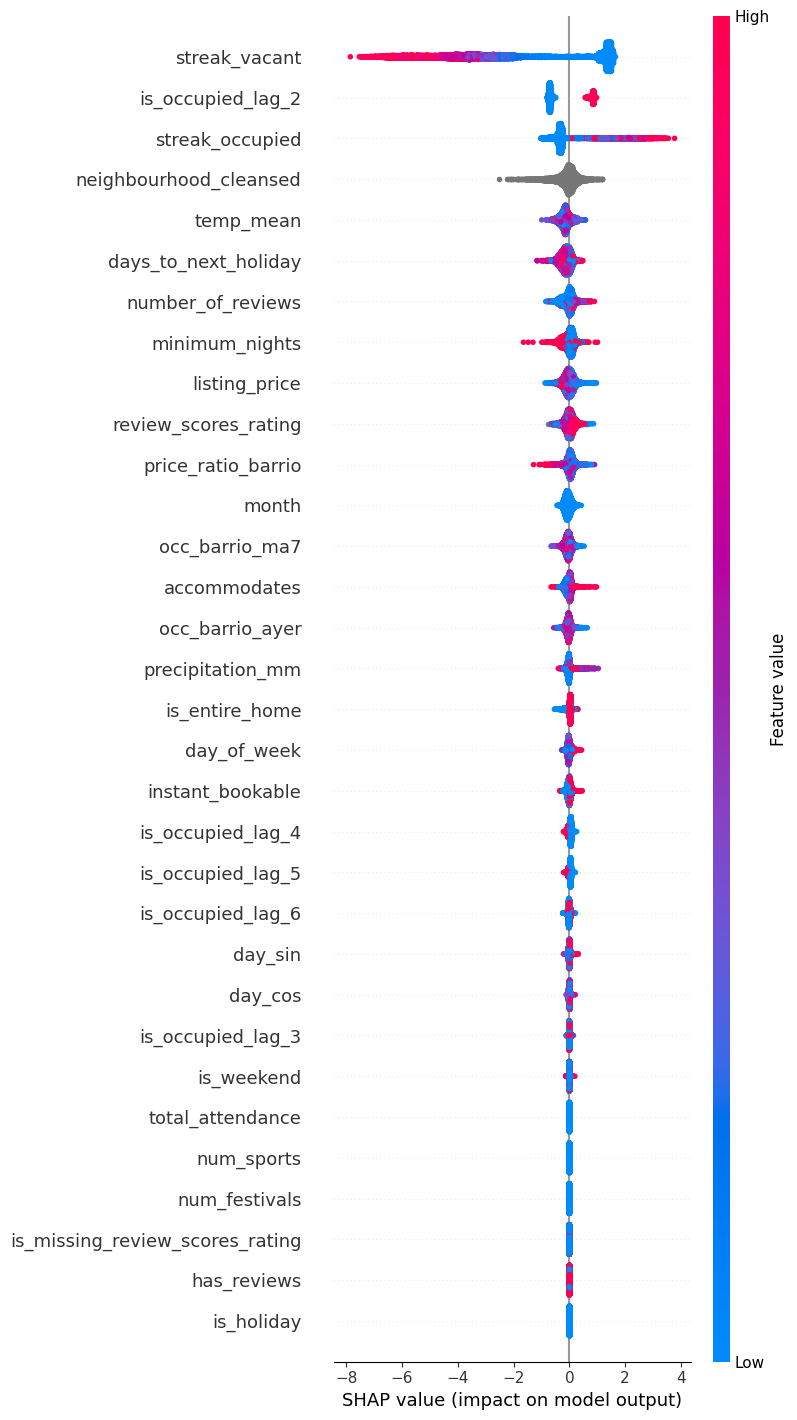

In [13]:
shap.summary_plot(shap_values.values, X_sample,max_display=44)

# #### COMPROBACIÓN DE DATA LEAKAGE 

In [22]:
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. ¿Qué pasa si nuestra única predicción es copiar lo que pasó ayer?
# Asumimos que lag_1 está en X_val_raw (si lo filtró el preprocesador, búscalo en el df_processed)
if 'is_occupied_lag_1' in X_val_raw.columns:
    y_pred_naive = X_val_raw['is_occupied_lag_1']
    acc_naive = accuracy_score(y_val, y_pred_naive)
    print(f"🎯 Accuracy del Modelo 'Copiar a Ayer': {acc_naive:.4f}")
    print(f"🚀 Accuracy de XGBoost: {eval_xgb['accuracy']:.4f}")
    print(f"Mejora real de ML: {(eval_xgb['accuracy'] - acc_naive)*100:.2f} puntos porcentuales")

🎯 Accuracy del Modelo 'Copiar a Ayer': 0.8934
🚀 Accuracy de XGBoost: 0.9497
Mejora real de ML: 5.63 puntos porcentuales


In [23]:
# 2. Entrenar un XGBoost SIN lags ni rachas
cols_temporales = [c for c in X_train_tree.columns if 'lag' in c or 'streak' in c or 'occ_barrio_ayer' in c]
X_train_amnesia = X_train_tree.drop(columns=cols_temporales)
X_val_amnesia = X_val_tree.drop(columns=cols_temporales)

modelo_amnesia = xgb.XGBClassifier(enable_categorical=True, tree_method='hist',
        device='cuda', random_state=42, n_jobs=-1)
modelo_amnesia.fit(X_train_amnesia, y_train)

auc_amnesia = roc_auc_score(y_val, modelo_amnesia.predict_proba(X_val_amnesia)[:, 1])
print(f"\n🧠 ROC AUC del Modelo Amnesia (Sin Lags ni Rachas): {auc_amnesia:.4f}")


🧠 ROC AUC del Modelo Amnesia (Sin Lags ni Rachas): 0.7422


In [24]:
# 3. Inspección visual de la frontera temporal
# Coge un ID de piso que esté en validación
sample_id = df_processed.loc[val_idx, 'listing_id'].iloc[0]

print(f"\n🔍 Inspeccionando transición Train -> Val para el piso: {sample_id}")
df_sample = df_processed[df_processed['listing_id'] == sample_id].sort_values('date')

# Mostrar los últimos 2 días de train y los primeros 2 de val para ese piso
train_dates = df_sample.loc[df_sample.index.isin(train_idx), ['date', 'is_occupied', 'is_occupied_lag_1', 'streak_occupied']].tail(2)
val_dates = df_sample.loc[df_sample.index.isin(val_idx), ['date', 'is_occupied', 'is_occupied_lag_1', 'streak_occupied']].head(2)

print("--- ÚLTIMOS DÍAS EN TRAIN ---")
print(train_dates)
print("--- PRIMEROS DÍAS EN VALIDACIÓN ---")
print(val_dates)


🔍 Inspeccionando transición Train -> Val para el piso: 2650947
--- ÚLTIMOS DÍAS EN TRAIN ---
            date  is_occupied  is_occupied_lag_1  streak_occupied
5463  2026-01-30            0                  0              0.0
5493  2026-01-31            0                  0              0.0
--- PRIMEROS DÍAS EN VALIDACIÓN ---
            date  is_occupied  is_occupied_lag_1  streak_occupied
5523  2026-02-01            0                  0              0.0
5553  2026-02-02            0                  0              0.0
